1. Content analysis: Analyze the content of social media data  to determine what topics are being given data set  using topic modelling, keyword extractor

In [12]:
import pandas as pd
import nltk
import gensim
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

In [13]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\Om
[nltk_data]     Shete\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Om
[nltk_data]     Shete\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
df = pd.read_csv('CSV/social_media_data.csv')
print(df.head())

   id                                               text
0   1  Just had a great meal at the new restaurant do...
1   2  I love going to the beach with my family in th...
2   3  Can't wait to see the new movie coming out thi...
3   4  Feeling stressed out at work today, need a vac...
4   5         I can't believe how fast time is flying by


In [15]:
stop_words = set(stopwords.words('english'))
print("Stopwords: ")
print(stop_words)
lemmatizer = WordNetLemmatizer()

Stopwords: 
{'aren', "it's", 'further', 'on', 'ourselves', 'under', 'himself', 'to', 'do', 'where', 'no', 'yourselves', 'needn', 'having', 'she', 'we', 'over', 'which', "doesn't", 'has', 'is', 'their', 'had', 'doesn', "won't", 'can', "he'll", 'ma', 'with', 'theirs', 'again', 'those', 'all', 'd', 'for', 'other', 'now', 'any', 'out', 'that', "didn't", 'wouldn', 'did', 'into', 'isn', 'yourself', 'there', 'are', 'won', 'o', 'should', 'him', 'about', "hadn't", 'down', "she'll", 'from', 'why', "she's", "should've", 'it', "i'd", 'shan', 'am', 'and', 'because', 'after', 'ours', 'of', 'have', 'be', "it'd", "couldn't", 'above', 'being', 'an', 'if', 'or', 'then', "wouldn't", 'was', "you're", "haven't", "we're", 'these', 'both', 'up', "i'll", 'our', "hasn't", 'here', 'whom', 'been', 'he', 'not', 'they', 'yours', "it'll", "wasn't", 'itself', 'myself', 'once', 'hers', 'so', "i've", 'y', 'haven', 'a', 'couldn', "we've", "shouldn't", 'some', "mightn't", "you'll", 'his', 'll', "shan't", "you'd", "that'

In [16]:
def pre_process(text):
    tokens = text.lower().split()
    lemma = [ lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    return lemma

In [17]:
df['tokens'] = df['text'].apply(pre_process)
print(df.head())

   id  ...                                             tokens
0   1  ...          [great, meal, new, restaurant, downtown!]
1   2  ...               [love, going, beach, family, summer]
2   3  ...    [can't, wait, see, new, movie, coming, weekend]
3   4  ...  [feeling, stressed, work, today,, need, vacation]
4   5  ...               [can't, believe, fast, time, flying]

[5 rows x 3 columns]


In [18]:
# Topic Modeling with lda

dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(token) for token in df['tokens']]

num_topics = 5
lda_model = LdaModel(num_topics=num_topics, corpus=corpus, id2word=dictionary, passes=20)

print("Topics: ")
for topic_id in lda_model.print_topics():
    print(f"Topic: {topic_id}")

Topics: 
Topic: (0, '0.056*"day" + 0.056*"movie" + 0.056*"watching" + 0.056*"home" + 0.056*"popcorn" + 0.056*"lazy" + 0.056*"eating" + 0.009*"stressed" + 0.009*"work" + 0.009*"today,"')
Topic: (1, '0.070*"can\'t" + 0.070*"believe" + 0.038*"start" + 0.038*"next" + 0.038*"excited" + 0.038*"graduated" + 0.038*"since" + 0.038*"college" + 0.038*"already" + 0.038*"year"')
Topic: (2, '0.028*"great" + 0.028*"sounded" + 0.028*"even" + 0.028*"concert" + 0.028*"live" + 0.028*"night" + 0.028*"amazing," + 0.028*"better" + 0.028*"last" + 0.028*"band"')
Topic: (3, '0.041*"family" + 0.041*"incredible" + 0.041*"mountains," + 0.041*"afternoon" + 0.041*"hiking" + 0.041*"spent" + 0.041*"view" + 0.041*"summer" + 0.041*"beach" + 0.041*"going"')
Topic: (4, '0.059*"feeling" + 0.059*"new" + 0.059*"need" + 0.059*"today," + 0.032*"job" + 0.032*"week!" + 0.032*"get" + 0.032*"motivation" + 0.032*"downtown!" + 0.032*"restaurant"')


In [22]:
for idx in range(num_topics):
    topic_info = lda_model.print_topic(idx, topn=10)
    word_and_weights = topic_info.split(" + ")
    print(word_and_weights)

    for item in word_and_weights:
        word, weight = item.split("*")
        print(f" - {word.strip()} (Weight: {weight.strip()})")

['0.056*"day"', '0.056*"movie"', '0.056*"watching"', '0.056*"home"', '0.056*"popcorn"', '0.056*"lazy"', '0.056*"eating"', '0.009*"stressed"', '0.009*"work"', '0.009*"today,"']
 - 0.056 (Weight: "day")
 - 0.056 (Weight: "movie")
 - 0.056 (Weight: "watching")
 - 0.056 (Weight: "home")
 - 0.056 (Weight: "popcorn")
 - 0.056 (Weight: "lazy")
 - 0.056 (Weight: "eating")
 - 0.009 (Weight: "stressed")
 - 0.009 (Weight: "work")
 - 0.009 (Weight: "today,")
['0.070*"can\'t"', '0.070*"believe"', '0.038*"start"', '0.038*"next"', '0.038*"excited"', '0.038*"graduated"', '0.038*"since"', '0.038*"college"', '0.038*"already"', '0.038*"year"']
 - 0.070 (Weight: "can't")
 - 0.070 (Weight: "believe")
 - 0.038 (Weight: "start")
 - 0.038 (Weight: "next")
 - 0.038 (Weight: "excited")
 - 0.038 (Weight: "graduated")
 - 0.038 (Weight: "since")
 - 0.038 (Weight: "college")
 - 0.038 (Weight: "already")
 - 0.038 (Weight: "year")
['0.028*"great"', '0.028*"sounded"', '0.028*"even"', '0.028*"concert"', '0.028*"live"',

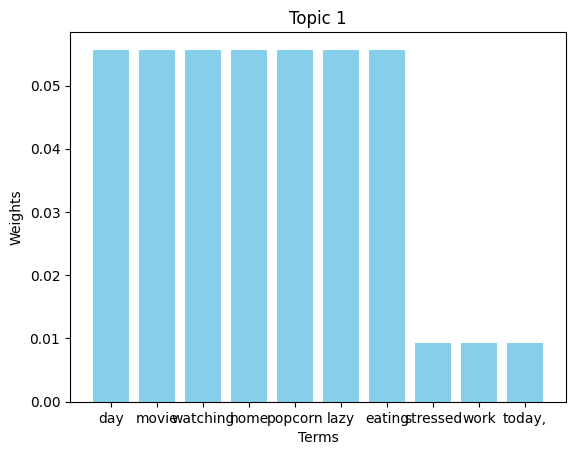

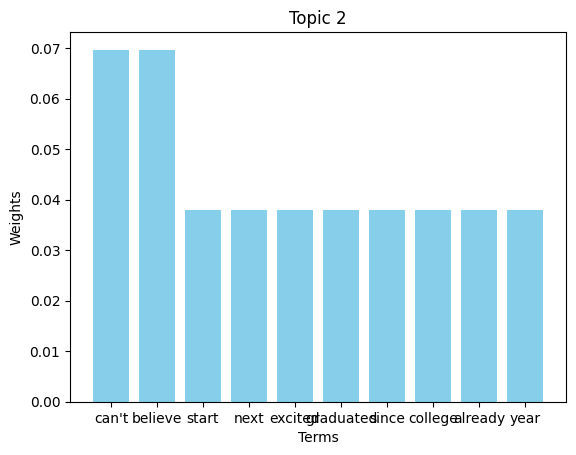

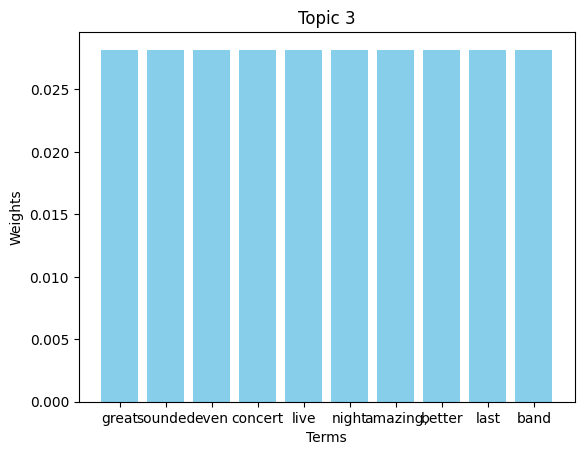

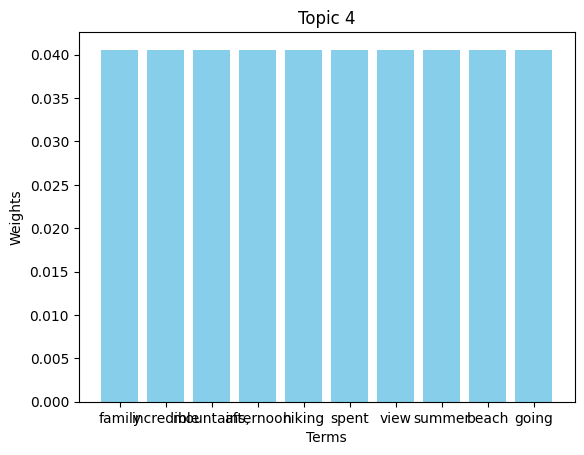

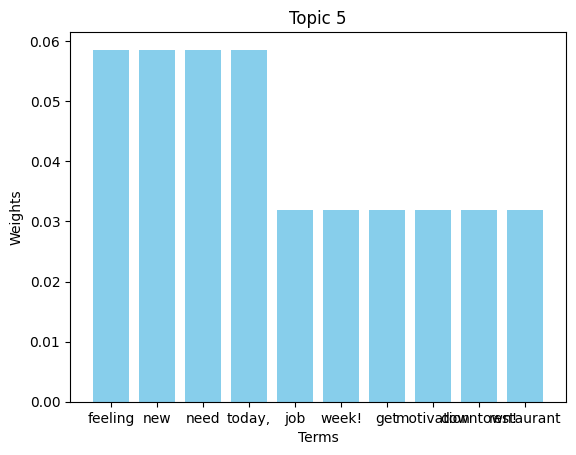

In [24]:
for idx, topic in enumerate(lda_model.show_topics(num_topics, formatted=False)):
    topic_term = [term[0] for term in topic[1]]
    topic_weight = [term[1] for term in topic[1]]

    plt.figure()
    plt.bar(topic_term, topic_weight, color='skyblue')
    plt.title(f"Topic {idx + 1}")
    plt.xlabel("Terms")
    plt.ylabel("Weights")
    plt.show()

In [11]:
# keyword extraction
all_tokens = [ token for tokens in df['tokens'] for token in tokens]
keyword_ctr = Counter(all_tokens)
print("\nKeywords Counts: \n", keyword_ctr)

tfidf = TfidfVectorizer(max_features=20, stop_words='english')
x = tfidf.fit_transform(df['text'])

tfidf_keyword = tfidf.get_feature_names_out()
print("\nTop TF-IDF Keywords: ", tfidf_keyword)


Keywords Counts: 
 Counter({'new': 3, "can't": 3, 'feeling': 3, 'day': 3, 'great': 2, 'family': 2, 'movie': 2, 'today,': 2, 'need': 2, 'believe': 2, 'excited': 2, 'start': 2, 'next': 2, 'meal': 1, 'restaurant': 1, 'downtown!': 1, 'love': 1, 'going': 1, 'beach': 1, 'summer': 1, 'wait': 1, 'see': 1, 'coming': 1, 'weekend': 1, 'stressed': 1, 'work': 1, 'vacation': 1, 'fast': 1, 'time': 1, 'flying': 1, 'concert': 1, 'last': 1, 'night': 1, 'amazing,': 1, 'band': 1, 'sounded': 1, 'even': 1, 'better': 1, 'live': 1, 'job': 1, 'week!': 1, 'motivation': 1, 'get': 1, 'spent': 1, 'afternoon': 1, 'hiking': 1, 'mountains,': 1, 'view': 1, 'incredible': 1, 'finished': 1, 'reading': 1, 'book,': 1, 'highly': 1, 'recommend': 1, 'it!': 1, 'lazy': 1, 'home': 1, 'watching': 1, 'eating': 1, 'popcorn': 1, 'grateful': 1, 'friend': 1, 'today': 1, 'weather': 1, 'perfect': 1, 'park': 1, 'already': 1, 'year': 1, 'since': 1, 'graduated': 1, 'college': 1, 'planning': 1, 'vacation!': 1})

Top TF-IDF Keywords:  ['bel